# Data exploration
## Understanding and cleaning the original data 

In [1]:
# importing all the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

## Importing original data from csv to pandas dataframe

In [2]:
path_to_raw_data = '../data/raw/Intuilize_MNSU_ACME_SalesData.csv'

In [3]:
# Load the dataset (update with the actual file path)
df = pd.read_csv(path_to_raw_data)

In [4]:
# Convert the date column to datetime format
df['SalesDate'] = pd.to_datetime(df['SalesDate'])

In [5]:
# Add month and year columns
df["Month"] = df["SalesDate"].dt.month
df["Year"] = df["SalesDate"].dt.year
# Calculate profit
df["Profit"] = df["ExtPrice"] - df["ExtCost"]

# Removing data from 2021 and 2025 since it is not complete

In [6]:
df_without_2021_2025 = df.drop(df[df["Year"].isin([2021, 2025])].index)

In [7]:
# Creating customer aliases for presentation purposes
unique_customers = df['CustomerName'].unique()
name_to_alias = {name: f"Customer {i+1}" for i, name in enumerate(unique_customers)}
df['customer_alias'] = df['CustomerName'].map(name_to_alias)

In [8]:
# Display basic info
display(df.info())
display(df.describe())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1214881 entries, 0 to 1214880
Data columns (total 25 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   BranchName       1214881 non-null  object        
 1   Ship2City        1212428 non-null  object        
 2   Ship2State       1203967 non-null  object        
 3   OrderNumber      1214881 non-null  int64         
 4   InvoiceNumber    1214881 non-null  int64         
 5   LineNumber       1214881 non-null  float64       
 6   OrderDate        1214881 non-null  object        
 7   SalesDate        1214881 non-null  datetime64[ns]
 8   SalesPersonID    1214881 non-null  object        
 9   SalesPersonName  1214881 non-null  object        
 10  ProductID        1214881 non-null  object        
 11  ProductGroupID   1214881 non-null  object        
 12  CustomerID       1214881 non-null  object        
 13  CustomerName     1214881 non-null  object        
 14  Ex

None

,OrderNumber,InvoiceNumber,LineNumber,SalesDate,ExtPrice,ExtCost,SalesQty,UnitPrice,UnitCost,UnitSize,Month,Year,Profit
count,1.214881e+06,1.214881e+06,1.214881e+06,1214881,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06,1.214881e+06
mean,1.855137e+06,1.850455e+06,8.809435e+00,2023-06-02 17:56:53.546182400,1.870054e+02,1.345191e+02,1.330688e+03,1.944600e+01,1.448746e+01,2.159939e+01,6.227071e+00,2.022945e+03,5.248629e+01
min,1.449717e+06,1.702585e+06,1.000000e+00,2021-10-15 00:00:00,1.000000e-02,1.000000e-02,1.000000e+00,1.000000e-04,2.032520e-05,4.800000e-03,1.000000e+00,2.021000e+03,-4.531822e+06
25%,1.782287e+06,1.773295e+06,2.000000e+00,2022-08-23 00:00:00,2.310000e+01,1.481000e+01,3.000000e+00,2.308696e-01,1.320000e-01,1.000000e+00,3.000000e+00,2.022000e+03,4.950000e+00
50%,1.852266e+06,1.847320e+06,5.000000e+00,2023-05-15 00:00:00,6.515000e+01,4.370000e+01,2.700000e+01,1.654583e+00,1.100000e+00,1.000000e+00,6.000000e+00,2.023000e+03,1.577000e+01
75%,1.929071e+06,1.926112e+06,1.200000e+01,2024-02-28 00:00:00,1.570100e+02,1.053000e+02,3.000000e+02,9.690000e+00,7.350000e+00,1.000000e+00,9.000000e+00,2.024000e+03,4.632000e+01
max,2.008561e+06,2.007571e+06,2.550000e+02,2025-01-24 00:00:00,3.912880e+05,4.532000e+06,3.967950e+06,5.320000e+04,5.320000e+04,5.000000e+04,1.200000e+01,2.025000e+03,3.912138e+05
std,8.799744e+04,8.852974e+04,1.073872e+01,NaN,1.104569e+03,4.169189e+03,1.008797e+04,1.380779e+02,1.314676e+02,4.219639e+02,3.434483e+00,8.502564e-01,4.183451e+03


BranchName             0
Ship2City           2453
Ship2State         10914
OrderNumber            0
InvoiceNumber          0
LineNumber             0
OrderDate              0
SalesDate              0
SalesPersonID          0
SalesPersonName        0
ProductID              0
ProductGroupID         0
CustomerID             0
CustomerName           0
ExtPrice               0
ExtCost                0
SalesQty               0
UnitPrice              0
UnitCost               0
UOM                    0
UnitSize               0
Month                  0
Year                   0
Profit                 0
customer_alias         0
dtype: int64

# Graphs for data vizualization and presentation

In [9]:
# Convert large numbers to a readable format
def format_millions(x, pos):
    return f'{x*1e-6:.1f}M'

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\3117369499.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cust.values, y=top_cust.index, palette="viridis")


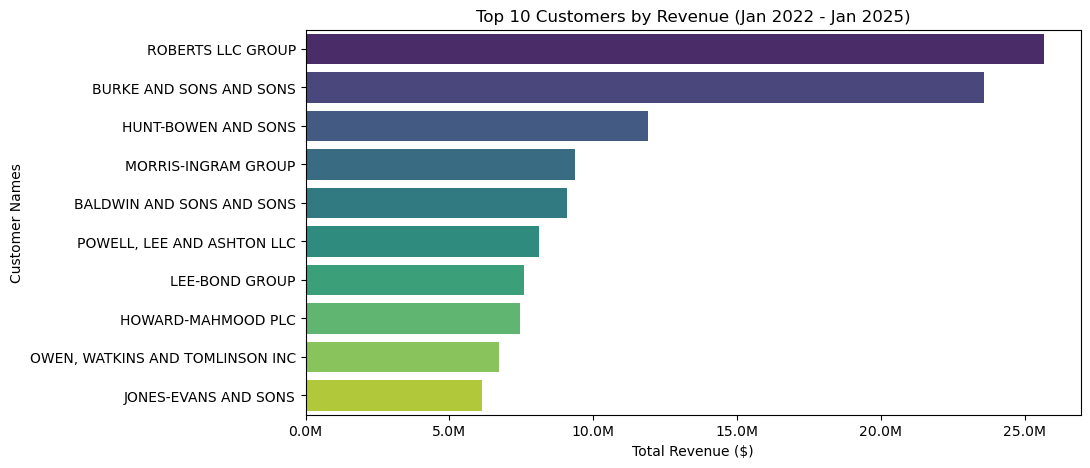

In [10]:
# Top 10 Customers by Revenue
top_cust = df.groupby("CustomerName")["ExtPrice"].sum().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_cust.values, y=top_cust.index, palette="viridis")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Customer Names")
plt.title("Top 10 Customers by Revenue (Jan 2022 - Jan 2025)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\1311868995.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cust.values, y=top_cust.index, palette="viridis")


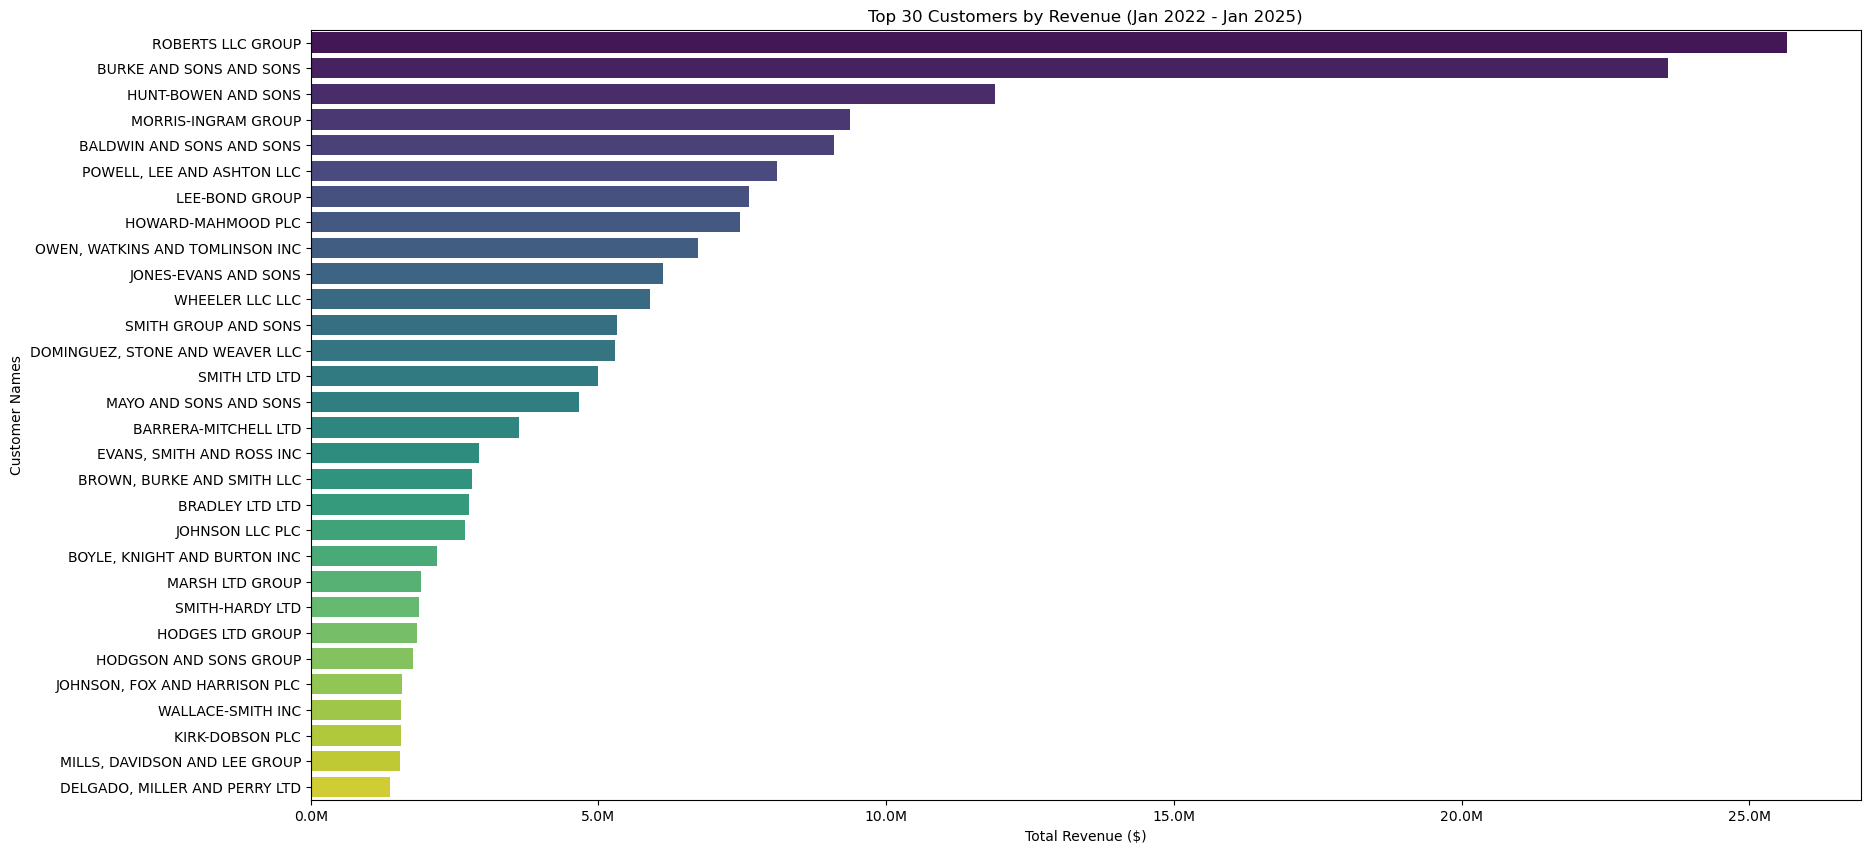

In [11]:
# Top 30 Customers by Revenue
top_cust = df.groupby("CustomerName")["ExtPrice"].sum().nlargest(30)
plt.figure(figsize=(20, 10))
sns.barplot(x=top_cust.values, y=top_cust.index, palette="viridis")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Customer Names")
plt.title("Top 30 Customers by Revenue (Jan 2022 - Jan 2025)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\2478471399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_profit_cust.values, y=top_profit_cust.index, palette="magma")


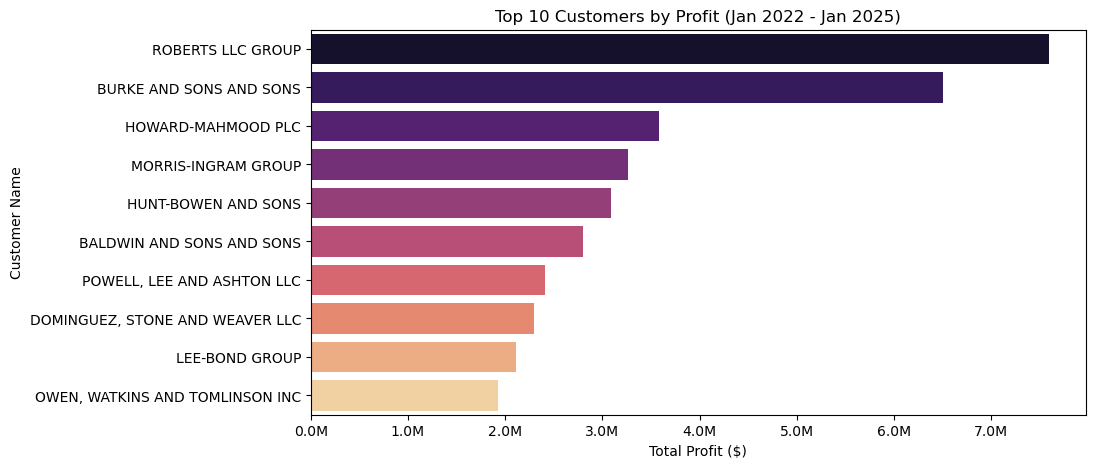

In [12]:

# Top Customers by Profit
top_profit_cust = df.groupby("CustomerName")["Profit"].sum().nlargest(10)
plt.figure(figsize=(10, 5))
sns.barplot(x=top_profit_cust.values, y=top_profit_cust.index, palette="magma")
plt.xlabel("Total Profit ($)")
plt.ylabel("Customer Name")
plt.title("Top 10 Customers by Profit (Jan 2022 - Jan 2025)")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

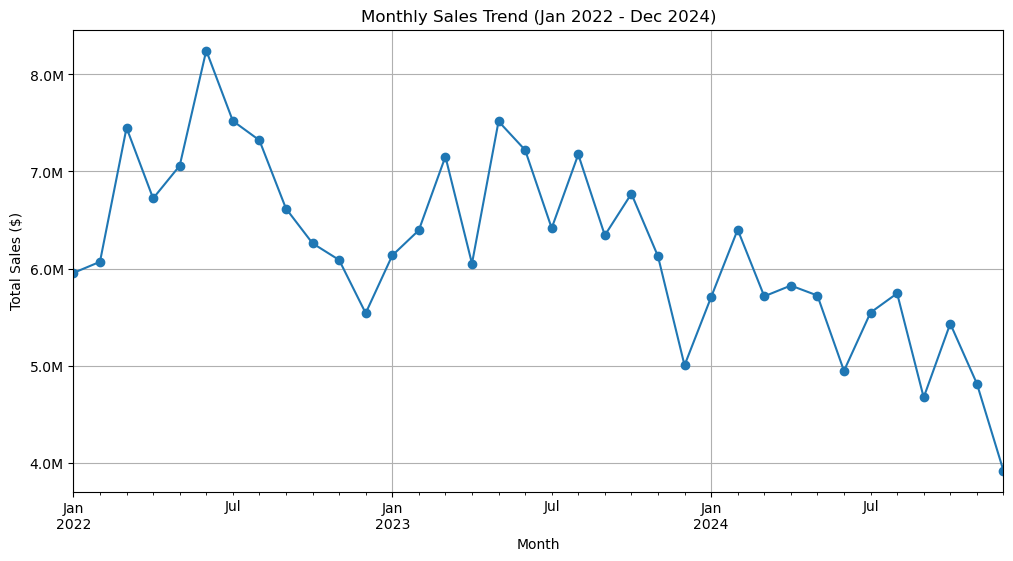

In [13]:
# Sales Trend Over Time
df_without_2021_2025["SalesDate"] = pd.to_datetime(df_without_2021_2025["SalesDate"])
sales_over_time = df_without_2021_2025.groupby(df_without_2021_2025["SalesDate"].dt.to_period("M"))["ExtPrice"].sum()
plt.figure(figsize=(12, 6))
sales_over_time.plot(marker='o', linestyle='-')
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trend (Jan 2022 - Dec 2024)")
plt.grid()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

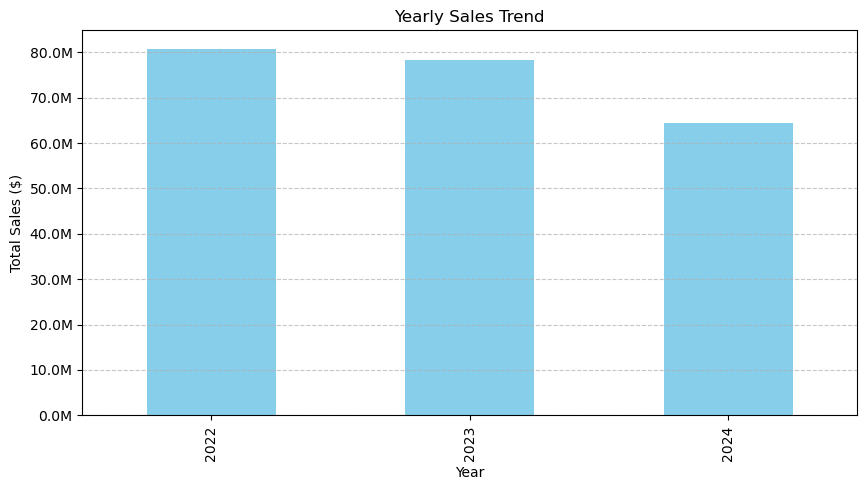

In [14]:
# Yearly Sales Trend
yearly_sales = df_without_2021_2025.groupby("Year")["ExtPrice"].sum()
plt.figure(figsize=(10, 5))
yearly_sales.plot(kind='bar', color='skyblue')
plt.xlabel("Year")
plt.ylabel("Total Sales ($)")
plt.title("Yearly Sales Trend")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

<Figure size 1200x600 with 0 Axes>

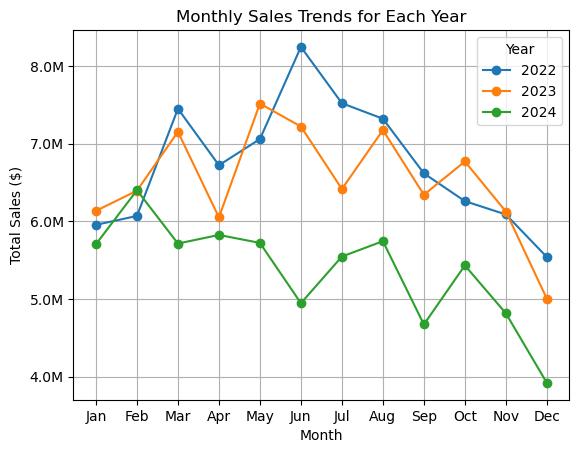

In [15]:
# Monthly Sales Trends for Each Year
monthly_trends = df_without_2021_2025.groupby(["Year", "Month"])["ExtPrice"].sum().unstack(level=0)
plt.figure(figsize=(12, 6))
monthly_trends.plot(marker='o', linestyle='-')
plt.xlabel("Month")
plt.ylabel("Total Sales ($)")
plt.title("Monthly Sales Trends for Each Year")
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(title="Year")
plt.grid()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

Number of customers in the data: 1046

In [16]:
df["CustomerName"].nunique()

1046

## Extracting customer specific data

In [17]:
# Aggregate revenue, profit, and frequency per customer while ensuring CustomerID is retained
customer_metrics = df.groupby(["CustomerID", "CustomerName"]).agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    PurchaseFrequency=("OrderNumber", "nunique"),
).reset_index()

In [18]:
# Highest revenue geenrating customers
customer_metrics.sort_values("TotalRevenue", ascending=False).head(10)

,CustomerID,CustomerName,TotalRevenue,TotalProfit,PurchaseFrequency
828,CUST8,ROBERTS LLC GROUP,25656506.16,7.592246e+06,12055
162,CUST2,BURKE AND SONS AND SONS,23592909.94,6.503200e+06,23910
1,CUST10,HUNT-BOWEN AND SONS,11896856.75,3.089858e+06,18522
540,CUST54,MORRIS-INGRAM GROUP,9363502.27,3.265337e+06,9914
584,CUST58,BALDWIN AND SONS AND SONS,9090502.63,2.798778e+06,680
129,CUST17,"POWELL, LEE AND ASHTON LLC",8111346.79,2.409317e+06,14317
163,CUST20,LEE-BOND GROUP,7608643.26,2.112092e+06,6379
717,CUST7,HOWARD-MAHMOOD PLC,7463341.79,3.585877e+06,7115
96,CUST14,"OWEN, WATKINS AND TOMLINSON INC",6732049.92,1.924431e+06,6143
725,CUST706,JONES-EVANS AND SONS,6117095.64,7.934478e+05,10309


In [19]:
# Lowest revenue generating customers
customer_metrics.sort_values("TotalRevenue", ascending=True).head(10)

,CustomerID,CustomerName,TotalRevenue,TotalProfit,PurchaseFrequency
1014,CUST967,BUCHANAN-FLORES LLC,0.58,0.05,1
16,CUST1012,GUTIERREZ-HUYNH LLC,4.06,2.44,1
1030,CUST981,GOODWIN-PERKINS INC,5.00,2.30,1
908,CUST871,CARR PLC INC,7.10,4.26,1
760,CUST738,WALKER GROUP PLC,7.59,2.73,1
1004,CUST958,CAMERON LLC INC,8.83,2.59,3
288,CUST312,DAVIS PLC GROUP,10.17,1.02,1
22,CUST1018,MORALES-MCCOY AND SONS,10.94,5.75,1
460,CUST468,"MARSH, JONES AND HOLMES LLC",10.95,4.49,1
1009,CUST962,TODD INC GROUP,12.05,7.24,1


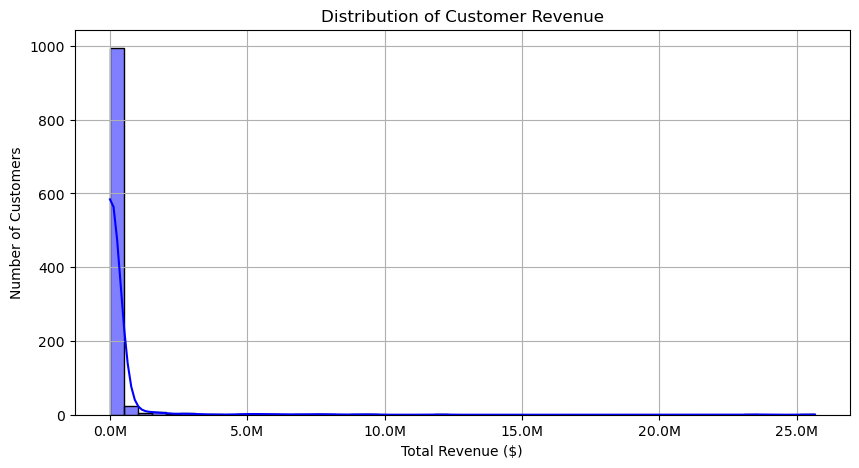

In [20]:
# Plot Revenue Distribution
plt.figure(figsize=(10, 5))
sns.histplot(customer_metrics["TotalRevenue"], bins=50, kde=True, color="blue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Revenue")
plt.grid()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

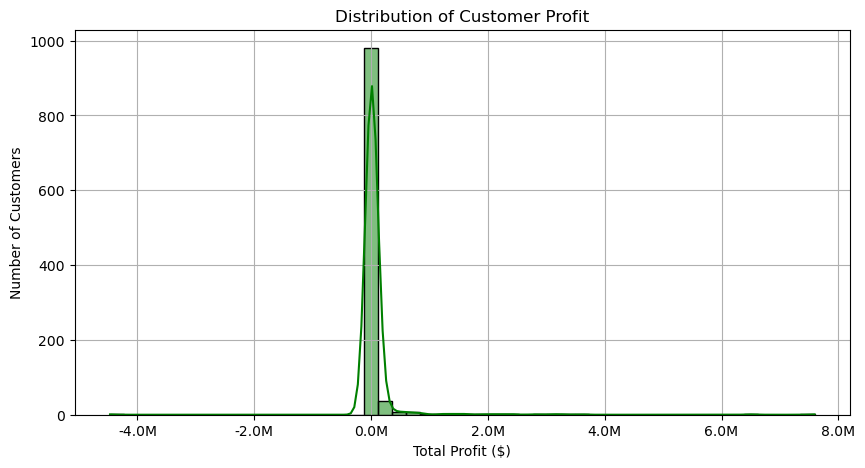

In [21]:
# Plot Profit Distribution
plt.figure(figsize=(10, 5))
sns.histplot(customer_metrics["TotalProfit"], bins=50, kde=True, color="green")
plt.xlabel("Total Profit ($)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Profit")
plt.grid()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

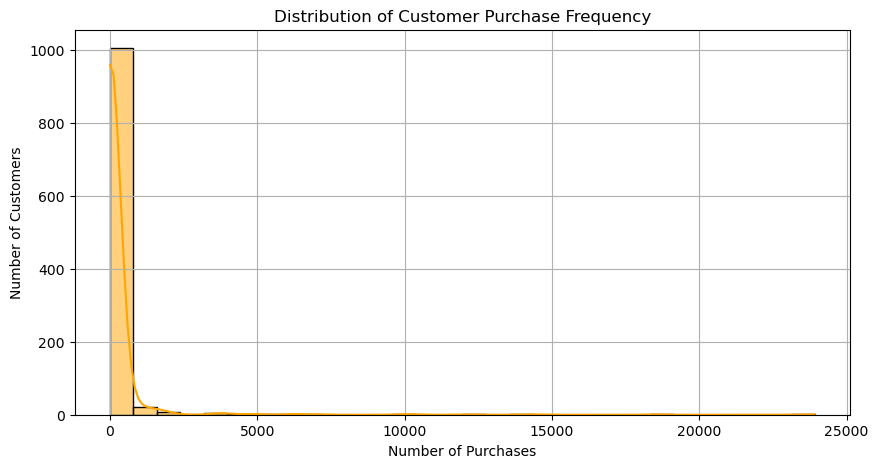

In [22]:
# Plot Purchase Frequency Distribution
plt.figure(figsize=(10, 5))
sns.histplot(customer_metrics["PurchaseFrequency"], bins=30, kde=True, color="orange")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Purchase Frequency")
plt.grid()

plt.show()

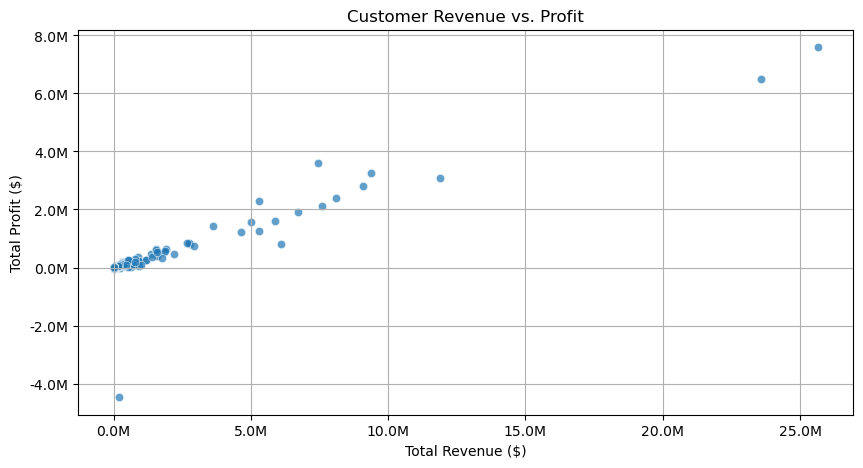

In [23]:
# Scatter Plot: Profit vs Revenue
plt.figure(figsize=(10, 5))
sns.scatterplot(x=customer_metrics["TotalRevenue"], y=customer_metrics["TotalProfit"], alpha=0.7)
plt.xlabel("Total Revenue ($)")
plt.ylabel("Total Profit ($)")
plt.title("Customer Revenue vs. Profit")
plt.grid()
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

In [24]:
print(customer_metrics.describe())

       TotalRevenue   TotalProfit  PurchaseFrequency
count  1.050000e+03  1.050000e+03        1050.000000
mean   2.163707e+05  6.072818e+04         214.247619
std    1.372365e+06  4.304843e+05        1288.469553
min    5.800000e-01 -4.470310e+06           1.000000
25%    1.087028e+03  3.639200e+02           3.250000
50%    5.120165e+03  1.894545e+03          12.000000
75%    2.986352e+04  1.160624e+04          50.750000
max    2.565651e+07  7.592246e+06       23910.000000


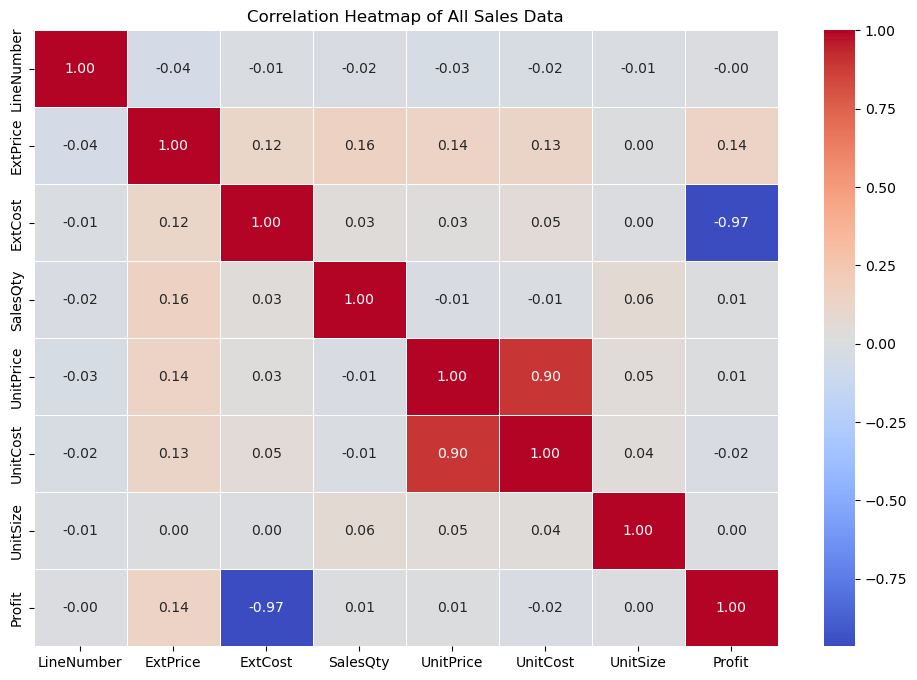

In [25]:
# Generate correlation heatmap for numerical features
numerical_features = ["LineNumber", "ExtPrice", "ExtCost", "SalesQty", "UnitPrice", "UnitCost", "UnitSize", "Profit"]
corr_matrix = df[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of All Sales Data")
plt.show()

In [26]:
# Aggregate customer-level metrics
customer_metrics = df.groupby("CustomerName").agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    TotalUnitPrice=("UnitPrice", "sum"),
    TotalSalesQty=("SalesQty", "sum"),
    OrderCount=("OrderNumber", "nunique"),
    AverageAmountSpent=("ExtPrice", "mean")
).reset_index()

## Feature Engineering

In [27]:
# Calculate customer lifetime (duration between first and last purchase)
customer_lifetime = df.groupby("CustomerName").agg(
    FirstPurchase=("SalesDate", "min"),
    LastPurchase=("SalesDate", "max")
).reset_index()

# Compute lifetime in days
customer_lifetime["CustomerLifetimeDays"] = (customer_lifetime["LastPurchase"] - customer_lifetime["FirstPurchase"]).dt.days

# Merge with customer_metrics
customer_metrics = df.groupby("CustomerName").agg(
    TotalRevenue=("ExtPrice", "sum"), # total revenue generated by the customer
    TotalProfit=("Profit", "sum"), # toatl profit generated by the customer
    TotalUnitPrice=("UnitPrice", "sum"), # total individual unit price for all purchases by the customer
    TotalSalesQty=("SalesQty", "sum"), # total quantity sold to the customer
    OrderCount=("OrderNumber", "nunique"), # total number of orders placed by the customer
    AverageAmountSpent=("ExtPrice", "mean"), # average amount spent by the customer
    NumDistinctProducts=("ProductID", "nunique"), # number of distinct products purchased by the customer
    NumDistinctProductGroups=("ProductGroupID", "nunique"), # number of distinct product groups purchased by the customer
    TopProductID=("ProductID", lambda x: x.value_counts().idxmax()), # most popular product purchased by the customer
    TopProductGroupID=("ProductGroupID", lambda x: x.value_counts().idxmax()), # most popular product group purchased by the customer
    ProductDiversityIndex=("ProductID", lambda x: len(x.unique()) / x.count()), # number of distinct products divided by the total sales quantity
    ProductConcentrationIndex=("ExtPrice", lambda x: x.max() / x.sum()), # revenue of the most expensive product divided by the total revenue
    TopProductRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductID"]).sum().max() / x.sum()), # revenue share of the most expensive product
    TopProductGroupRevenueShare=("ExtPrice", lambda x: x.groupby(df["ProductGroupID"]).sum().max() / x.sum()) # revenue share of the most expensive product group
).reset_index()

customer_metrics = customer_metrics.merge(customer_lifetime[["CustomerName", "CustomerLifetimeDays"]], on="CustomerName", how="left")

# Display the updated customer metrics with the new feature
print(customer_metrics.head())

                      CustomerName  TotalRevenue  TotalProfit  TotalUnitPrice  \
0               ADAMS PLC AND SONS      59976.78     25827.38     5183.514850   
1                    ADAMS PLC LTD       2039.03       639.50     1478.530800   
2  AHMED, MURPHY AND STEVENSON LLC        646.61       272.79        3.407011   
3               AHMED-BAILEY GROUP      32935.80      9222.00    28544.360000   
4                AKHTAR-AKHTAR LTD       4033.12      1531.66       47.272289   

   TotalSalesQty  OrderCount  AverageAmountSpent  NumDistinctProducts  \
0         150624          44          199.258405                  125   
1             80           7          107.317368                   16   
2           3194           2           49.739231                   13   
3             15          10         2533.523077                    1   
4            605           3          806.624000                    3   

   NumDistinctProductGroups TopProductID TopProductGroupID  \
0           

Looking at the features from below, the profits is not really affected by the avg price of each individual product.
Most of the profits are from bulk orders of products with low price.

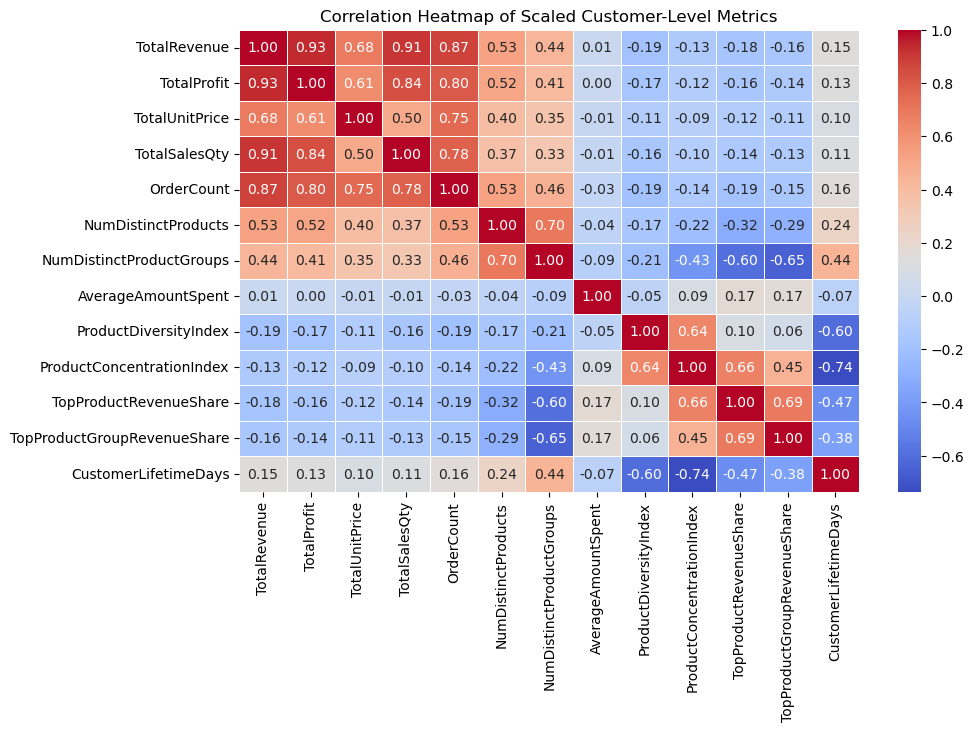

In [28]:
features = ["TotalRevenue", 
            "TotalProfit", 
            "TotalUnitPrice", 
            "TotalSalesQty", 
            "OrderCount", 
            "NumDistinctProducts", 
            "NumDistinctProductGroups",
            "AverageAmountSpent", 
            "ProductDiversityIndex", 
            "ProductConcentrationIndex", 
            "TopProductRevenueShare", 
            "TopProductGroupRevenueShare", 
            "CustomerLifetimeDays"]
# Standardize features before checking correlation
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_metrics[features])

# Create a DataFrame with the scaled features
scaled_customer_metrics = pd.DataFrame(scaled_features, columns=features)

# Generate correlation heatmap for scaled customer-level data
scaled_customer_corr_matrix = scaled_customer_metrics.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(scaled_customer_corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap of Scaled Customer-Level Metrics")
plt.show()

# Initial model testing on just few features

In [29]:
# Standardize features for clustering
features = ["TotalRevenue", "TotalProfit", "TotalSalesQty", "OrderCount"]
scaler = StandardScaler()
# scaling features to ensure bias is removed
customer_metrics_scaled = scaler.fit_transform(customer_metrics[features])

In [30]:
# Apply K-Means clustering
# 3 seems to be the optimal cluster number
# random state is just for reproducibility
# Runs the algorithm 10 times with different initializations and selects the best one to avoid poor local minima.
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_metrics["Cluster"] = kmeans.fit_predict(customer_metrics_scaled)

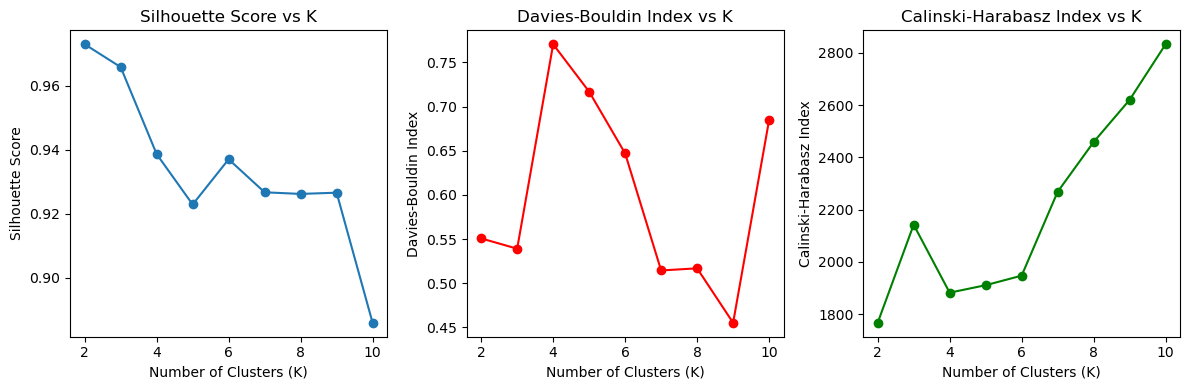

In [31]:
# Range of K values to try
K_range = range(2, 11)

# Lists to store the scores
silhouette_scores = []
davies_bouldin_scores = []
calinski_harabasz_scores = []

for K in K_range:
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    clusters = kmeans.fit_predict(customer_metrics_scaled)

    # Compute metrics
    silhouette_scores.append(silhouette_score(customer_metrics_scaled, clusters))
    davies_bouldin_scores.append(davies_bouldin_score(customer_metrics_scaled, clusters))
    calinski_harabasz_scores.append(calinski_harabasz_score(customer_metrics_scaled, clusters))

# Plot the results
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs K')

plt.subplot(1, 3, 2)
plt.plot(K_range, davies_bouldin_scores, marker='o', color='r')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Davies-Bouldin Index')
plt.title('Davies-Bouldin Index vs K')

plt.subplot(1, 3, 3)
plt.plot(K_range, calinski_harabasz_scores, marker='o', color='g')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Calinski-Harabasz Index')
plt.title('Calinski-Harabasz Index vs K')

plt.tight_layout()
plt.show()

In [32]:

# Calculate the Davies-Bouldin Index
davies_bouldin_index = davies_bouldin_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The Davies-Bouldin Index for the KMeans model is: {davies_bouldin_index}")

# Calculate the Calinski-Harabasz Index
calinski_harabasz_index = calinski_harabasz_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The Calinski-Harabasz Index for the KMeans model is: {calinski_harabasz_index}")
# Calculate the silhouette score
silhouette_avg = silhouette_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The average silhouette score for the KMeans model is: {silhouette_avg}")

The Davies-Bouldin Index for the KMeans model is: 0.539039570231541
The Calinski-Harabasz Index for the KMeans model is: 2142.454089770905
The average silhouette score for the KMeans model is: 0.9658309733446923


In [33]:
customer_metrics["Cluster"].value_counts()

Cluster
0    1033
1      11
2       2
Name: count, dtype: int64

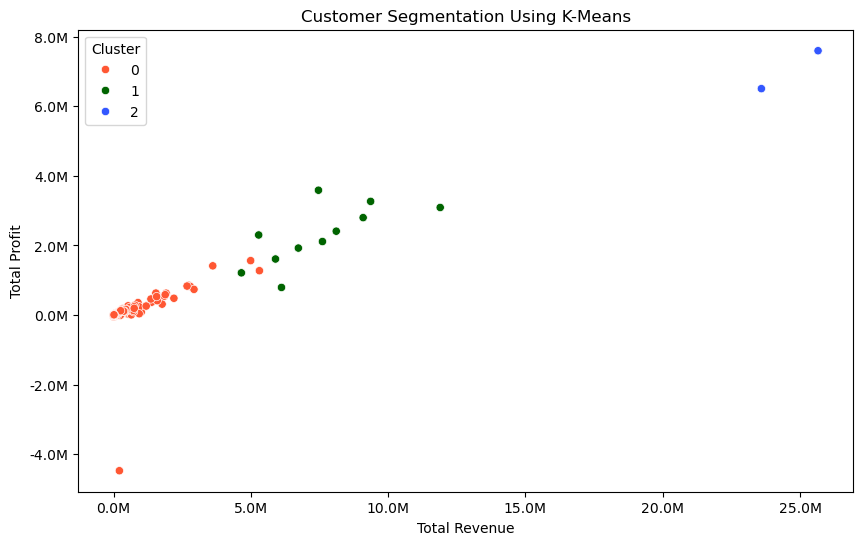

In [34]:
# Visualizing the clusters
plt.figure(figsize=(10, 6))
custom_palette = ["#FF5733", "#006400", "#3357FF"]
sns.set_palette(custom_palette)
sns.scatterplot(x=customer_metrics["TotalRevenue"], y=customer_metrics["TotalProfit"], hue=customer_metrics["Cluster"], palette=custom_palette)
plt.xlabel("Total Revenue")
plt.ylabel("Total Profit")
plt.title("Customer Segmentation Using K-Means")
plt.legend(title="Cluster")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

removing the highest outliers and working on the denser populated area

In [35]:
# Separate the customers in Cluster 2
diamond_plus_customers = customer_metrics[customer_metrics["Cluster"] == 2]

In [36]:
# Remove the customers in Cluster 2 from the original dataframe
customer_metrics = customer_metrics[customer_metrics["Cluster"] != 2]

Super Top customers:-
BURKE AND SONS AND SONS
ROBERTS LLC GROUP

In [37]:
# Display the outliers
print(diamond_plus_customers["CustomerName"].head())

133    BURKE AND SONS AND SONS
773          ROBERTS LLC GROUP
Name: CustomerName, dtype: object


The customer with negative profit is just due to 1 transaction record.
This is a record from 2024.
Name of the customer is VELASQUEZ INC INC


In [38]:
df[df["Profit"] == -4531822.4][["CustomerName","Month", "Year","ExtCost","ExtPrice", "Profit"]]

,CustomerName,Month,Year,ExtCost,ExtPrice,Profit
6468,VELASQUEZ INC INC,5,2024,4532000.0,177.6,-4531822.4


In [39]:

# Get the CustomerID of the removed customers
removed_customers = customer_metrics[customer_metrics["TotalProfit"] < -4_000_000]["CustomerName"]
removed_customer_ids = df[df["CustomerName"].isin(removed_customers)]["CustomerID"].unique()

# Remove customers with profit below -4 million
customer_metrics = customer_metrics[customer_metrics["TotalProfit"] >= -4_000_000]

print("Customer IDs of removed customers:", removed_customer_ids, "Name: ", removed_customers)

Customer IDs of removed customers: ['CUST18'] Name:  930    VELASQUEZ INC INC
Name: CustomerName, dtype: object


In [40]:
# scaling features to ensure bias is removed
customer_metrics_scaled = scaler.fit_transform(customer_metrics[features])

In [41]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
customer_metrics["Cluster"] = kmeans.fit_predict(customer_metrics_scaled)

In [42]:
# Calculate the Davies-Bouldin Index
davies_bouldin_index = davies_bouldin_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The Davies-Bouldin Index for the KMeans model is: {davies_bouldin_index}")

The Davies-Bouldin Index for the KMeans model is: 0.7653689577289836


In [43]:
# Calculate the Calinski-Harabasz Index
calinski_harabasz_index = calinski_harabasz_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The Calinski-Harabasz Index for the KMeans model is: {calinski_harabasz_index}")

The Calinski-Harabasz Index for the KMeans model is: 1879.826431188832


In [44]:
# Calculate the silhouette score
silhouette_avg = silhouette_score(customer_metrics_scaled, customer_metrics["Cluster"])
print(f"The average silhouette score for the KMeans model is: {silhouette_avg}")

The average silhouette score for the KMeans model is: 0.939904348916971


C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\755750183.py:21: UserWarning: The palette list has more values (15) than needed (3), which may not be intended.
  sns.scatterplot(x=customer_metrics["TotalRevenue"], y=customer_metrics["TotalProfit"], hue=customer_metrics["Cluster"], palette=custom_palette)


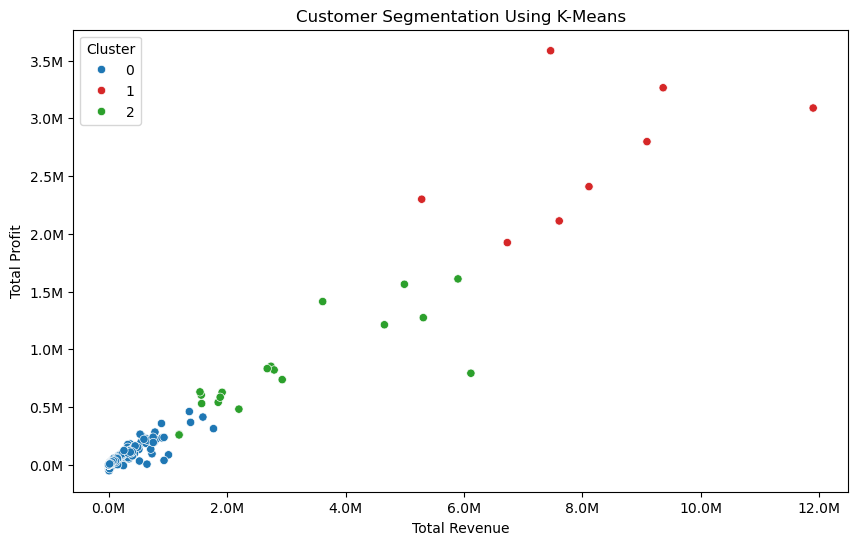

In [45]:
# Visualizing the clusters
plt.figure(figsize=(10, 6))
custom_palette = [
    "#1f77b4",  # Blue
    "#d62728",  # Red
    "#2ca02c",  # Green
    "#ff7f0e",  # Orange
    "#9467bd",  # Purple
    "#8c564b",  # Brown
    "#e377c2",  # Pink
    "#7f7f7f",  # Gray
    "#bcbd22",  # Yellow
    "#17becf",  # Cyan
    "#0055A4",  # Dark Blue
    "#800000",  # Dark Red
    "#008080",  # Teal
    "#FF00FF",  # Magenta
    "#FFD700"   # Gold
]
sns.set_palette(custom_palette)
sns.scatterplot(x=customer_metrics["TotalRevenue"], y=customer_metrics["TotalProfit"], hue=customer_metrics["Cluster"], palette=custom_palette)
plt.xlabel("Total Revenue")
plt.ylabel("Total Profit")
plt.title("Customer Segmentation Using K-Means")
plt.legend(title="Cluster")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

# Getting product specific information 

Number of unique products are 37935


In [46]:
#print(f"number of unique products: {df["ProductID"].nunique()}")

In [47]:
# Aggregate product-level metrics
product_metrics = df.groupby(["ProductID", "ProductGroupID"]).agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    TotalSalesQty=("SalesQty", "sum"),
    OrderCount=("OrderNumber", "nunique")
).reset_index()

# Identify the top-performing products based on TotalRevenue
top_products = product_metrics.sort_values(by="TotalRevenue", ascending=False).head(10)

# Segment the top-performing products
top_products["Segment"] = "Top Performer"

# Display the top-performing products
print(top_products)

         ProductID ProductGroupID  TotalRevenue  TotalProfit  TotalSalesQty  \
28640  TPY-784-AH5   PROD.Group11    1750147.40  445067.9600        2969800   
17151  LTW-808-EY9   PROD.Group12    1662673.19  383408.9500       21210000   
24092  QMV-253-SG1    PROD.Group2    1376112.63  268590.4300        1071600   
21129  OMJ-840-XM1   PROD.Group12    1235011.25  504336.8596       43690500   
6667   ENW-117-WC3    PROD.Group2    1058026.78  196492.4500         252120   
18532  MRO-745-GA3    PROD.Group2    1038695.37  354793.0200         112261   
16626  LKQ-740-EH7    PROD.Group3    1034618.67  200130.3900          14001   
5651   DVX-444-HZ4   PROD.Group12    1031212.32  225642.5100        1443576   
29827  UKP-055-DR8    PROD.Group3    1029200.69  396806.1100       62480844   
36903  ZHF-896-XJ3   PROD.Group12     941980.83  219831.7900          41246   

       OrderCount        Segment  
28640         668  Top Performer  
17151         613  Top Performer  
24092         346  Top Pe

In [48]:
# product alias for better visualization
unique_products = df['ProductID'].unique()
name_to_alias = {name: f"Product {i+1}" for i, name in enumerate(unique_products)}
df['product_alias'] = df['ProductID'].map(name_to_alias)

In [49]:
# Aggregate product-level metrics
product_profit = df.groupby(["product_alias", "ProductGroupID"]).agg(
    TotalRevenue=("ExtPrice", "sum"),
    TotalProfit=("Profit", "sum"),
    TotalSalesQty=("SalesQty", "sum"),
    TotalOrders=("product_alias", "count")
).reset_index()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\1924420044.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TotalProfit", y="product_alias", data=top_products, palette="viridis")


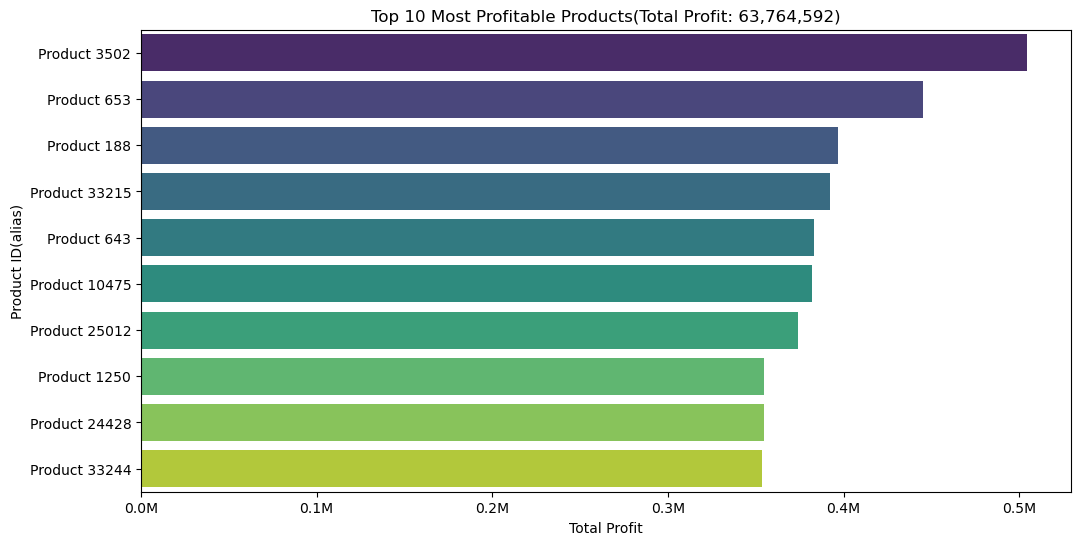

In [50]:

# Sort by highest profit
top_products = product_profit.sort_values(by="TotalProfit", ascending=False).head(10)

# Visualizing top 10 profitable products
plt.figure(figsize=(12, 6))
sns.barplot(x="TotalProfit", y="product_alias", data=top_products, palette="viridis")
plt.xlabel("Total Profit")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.ylabel("Product ID(alias)")
plt.title(f"Top 10 Most Profitable Products(Total Profit: {df['Profit'].sum():,.0f})")
plt.show()


C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\1508896201.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TotalSalesQty", y="product_alias", data=top_products, palette="viridis")


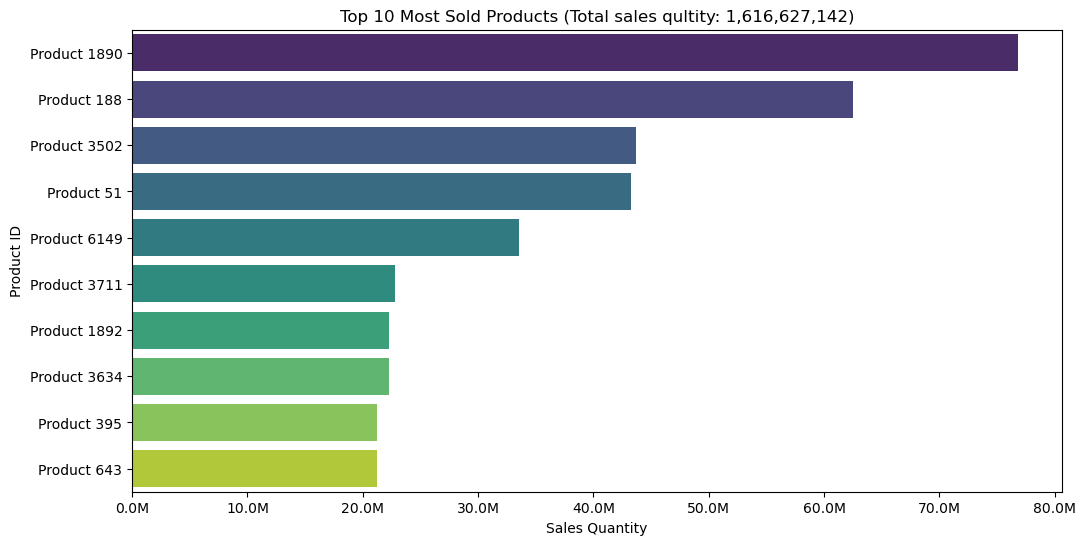

In [51]:
# Sort by highest profit
top_products = product_profit.sort_values(by="TotalSalesQty", ascending=False).head(10)
# Visualizing top 10 most sold products
plt.figure(figsize=(12, 6))
sns.barplot(x="TotalSalesQty", y="product_alias", data=top_products, palette="viridis")
plt.xlabel("Sales Quantity")
plt.ylabel("Product ID")
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.title(f"Top 10 Most Sold Products (Total sales qultity: {df['SalesQty'].sum():,.0f})")
plt.show()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\4198643813.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Category", y="TotalProfit", data=profit_comparison, palette="viridis")


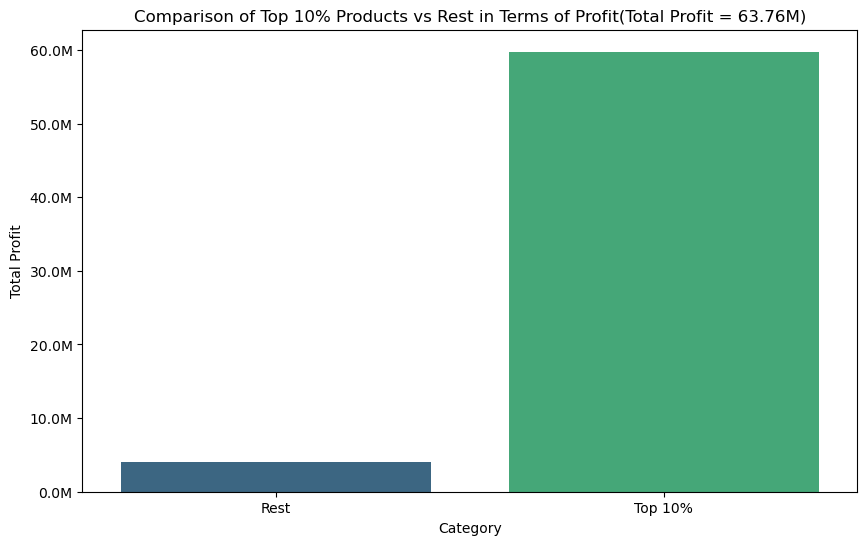

In [52]:
# Calculate the threshold for the top 10% products based on total profit
threshold = product_profit["TotalProfit"].quantile(0.90)

# Categorize products as "Top 10%" or "Rest"
product_profit["Category"] = np.where(product_profit["TotalProfit"] >= threshold, "Top 10%", "Rest")

# Aggregate total profit for each category
profit_comparison = product_profit.groupby("Category")["TotalProfit"].sum().reset_index()

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="Category", y="TotalProfit", data=profit_comparison, palette="viridis")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.title("Comparison of Top 10% Products vs Rest in Terms of Profit(Total Profit = {:.2f}M)".format(profit_comparison["TotalProfit"].sum() * 1e-6))
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\2968664805.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="SalesQtyCategory", y="TotalSalesQty", data=sales_qty_comparison, palette="viridis")


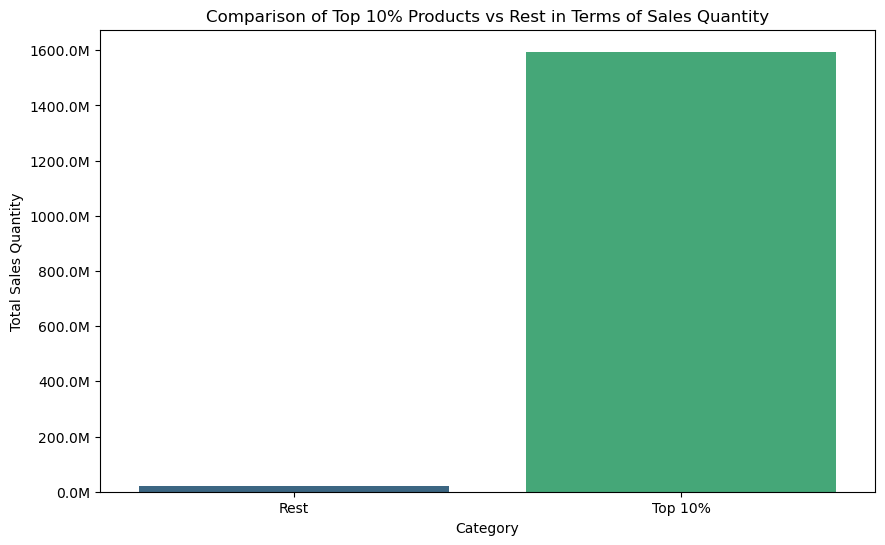

In [53]:
# Calculate the threshold for the top 10% products based on total sales quantity
threshold_sales_qty = product_profit["TotalSalesQty"].quantile(0.90)

# Categorize products as "Top 10%" or "Rest"
product_profit["SalesQtyCategory"] = np.where(product_profit["TotalSalesQty"] >= threshold_sales_qty, "Top 10%", "Rest")

# Aggregate total sales quantity for each category
sales_qty_comparison = product_profit.groupby("SalesQtyCategory")["TotalSalesQty"].sum().reset_index()

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="SalesQtyCategory", y="TotalSalesQty", data=sales_qty_comparison, palette="viridis")
plt.xlabel("Category")
plt.ylabel("Total Sales Quantity")
plt.title("Comparison of Top 10% Products vs Rest in Terms of Sales Quantity")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.show()

C:\Users\andyh\AppData\Local\Temp\ipykernel_18732\1837320461.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="TotalOrdersCategory", y="TotalOrders", data=total_orders_comparison, palette="viridis")


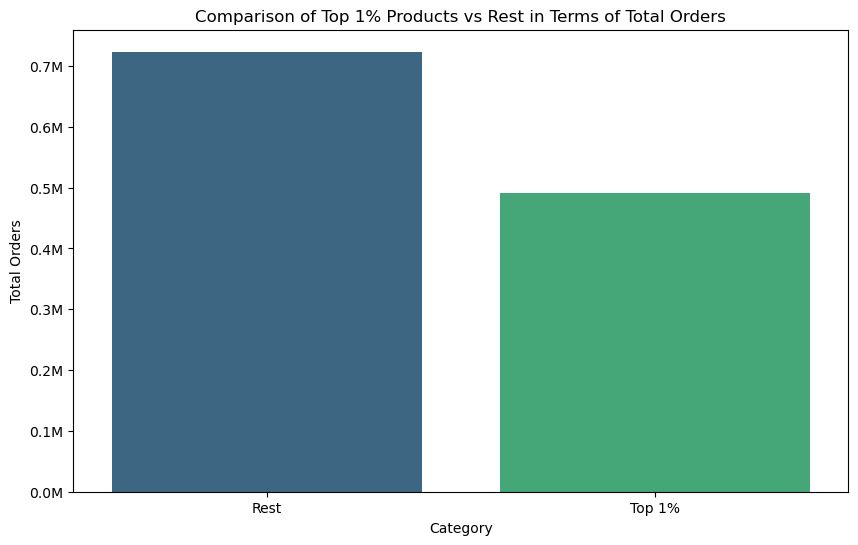

In [54]:
# Calculate the threshold for the top 10% products based on total orders
threshold_total_orders = product_profit["TotalOrders"].quantile(0.99)

# Categorize products as "Top 1%" or "Rest"
product_profit["TotalOrdersCategory"] = np.where(product_profit["TotalOrders"] >= threshold_total_orders, "Top 1%", "Rest")

# Aggregate total orders for each category
total_orders_comparison = product_profit.groupby("TotalOrdersCategory")["TotalOrders"].sum().reset_index()

# Plot the comparison
plt.figure(figsize=(10, 6))
sns.barplot(x="TotalOrdersCategory", y="TotalOrders", data=total_orders_comparison, palette="viridis")
plt.xlabel("Category")
plt.ylabel("Total Orders")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.title("Comparison of Top 1% Products vs Rest in Terms of Total Orders")
plt.show()

In [55]:
# Sort by highest profit
most_profitable_products = product_profit.sort_values(by="TotalProfit", ascending=False).head(10)

# Extract the product IDs
most_profitable_product_ids = most_profitable_products["product_alias"].tolist()
print(most_profitable_products[['product_alias', 'TotalProfit']])

       product_alias  TotalProfit
27802   Product 3502  504336.8596
34081    Product 653  445067.9600
9778     Product 188  396806.1100
25797  Product 33215  392060.7200
33970    Product 643  383408.9500
530    Product 10475  381975.5000
16683  Product 25012  374195.0200
2780    Product 1250  354793.0200
16033  Product 24428  354769.1300
25829  Product 33244  353678.9400


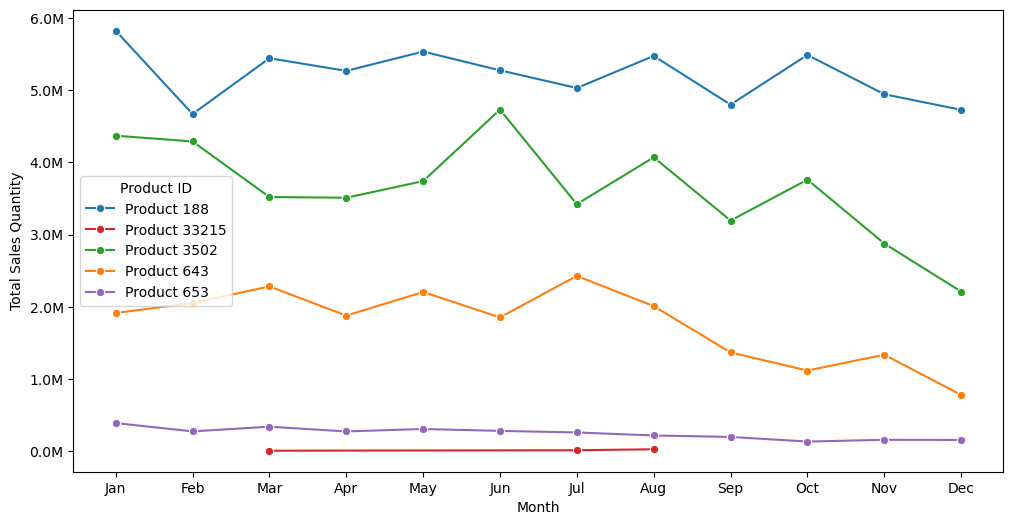

In [57]:
monthly_sales = df.groupby(["product_alias", "Month"]).agg(
    TotalSales=("SalesQty", "sum")
).reset_index()
# Sort by highest profit
top_products = product_profit.sort_values(by="TotalProfit", ascending=False).head(10)

# Visualizing seasonality for top 5 profitable products
top_5_products = top_products["product_alias"].head(5)
seasonal_data = monthly_sales[monthly_sales["product_alias"].isin(top_5_products)]

plt.figure(figsize=(12, 6))
sns.lineplot(x="Month", y="TotalSales", hue="product_alias", data=seasonal_data, marker="o")
plt.xlabel("Month")
plt.ylabel("Total Sales Quantity")
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
#plt.title(f"Seasonality of Top 5 Profitable Products(Overall sales quantity: {product_profit["TotalSalesQty"].sum():,})") # this is the total sales quantity of all products
plt.legend(title="Product ID")
plt.show()


There are 72 Prouduct groups in the data

In [58]:
df["ProductGroupID"].nunique()

72

# Checking for product sales trends

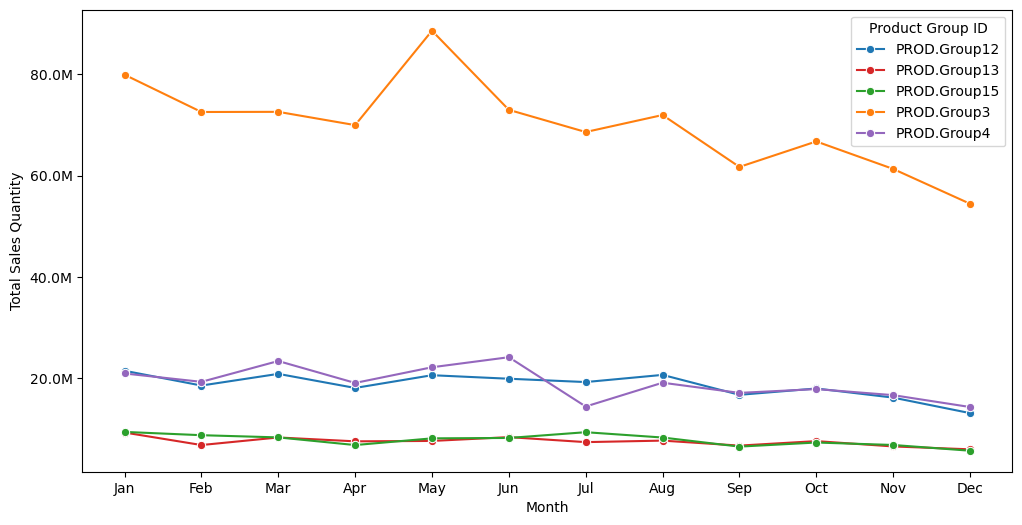

In [60]:
monthly_sales = df.groupby(["ProductGroupID", "Month"]).agg(
    TotalSales=("SalesQty", "sum")
).reset_index()

# Visualizing seasonality for top 5 product groups with the most total sales
top_5_product_groups = monthly_sales.groupby("ProductGroupID")["TotalSales"].sum().nlargest(5).index
seasonal_data = monthly_sales[monthly_sales["ProductGroupID"].isin(top_5_product_groups)]

plt.figure(figsize=(12, 6))
sns.lineplot(x="Month", y="TotalSales", hue="ProductGroupID", data=seasonal_data, marker="o")
plt.xlabel("Month")
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.ylabel("Total Sales Quantity")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
#plt.title(f"Seasonality of Top 5 Profitable Product groups (Sales Quantity = {(monthly_sales["TotalSales"].sum()):,})")
plt.legend(title="Product Group ID")
plt.show()

These are just top 1 comparisons

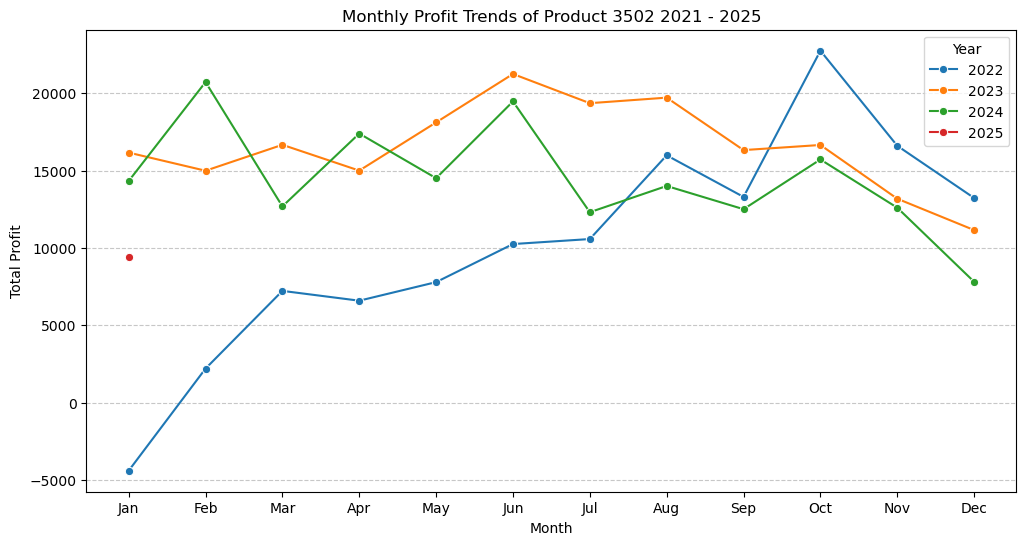

In [61]:

# Step 1: Identify the most profitable product
most_profitable_product = product_profit.sort_values(by="TotalProfit", ascending=False).iloc[0]["product_alias"]

# Step 2: Filter the dataset for this product
top_product_sales = df[df["product_alias"] == most_profitable_product]

# Step 3: Aggregate monthly profit by year
monthly_trends = top_product_sales.groupby(["Year", "Month"]).agg(TotalProfit=("Profit", "sum")).reset_index()

# Step 4: Plot the monthly trends for each year
plt.figure(figsize=(12, 6))
sns.lineplot(x="Month", y="TotalProfit", hue="Year", data=monthly_trends, marker="o", palette="tab10")

# Formatting the graph
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.title(f"Monthly Profit Trends of {most_profitable_product} 2021 - 2025")
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


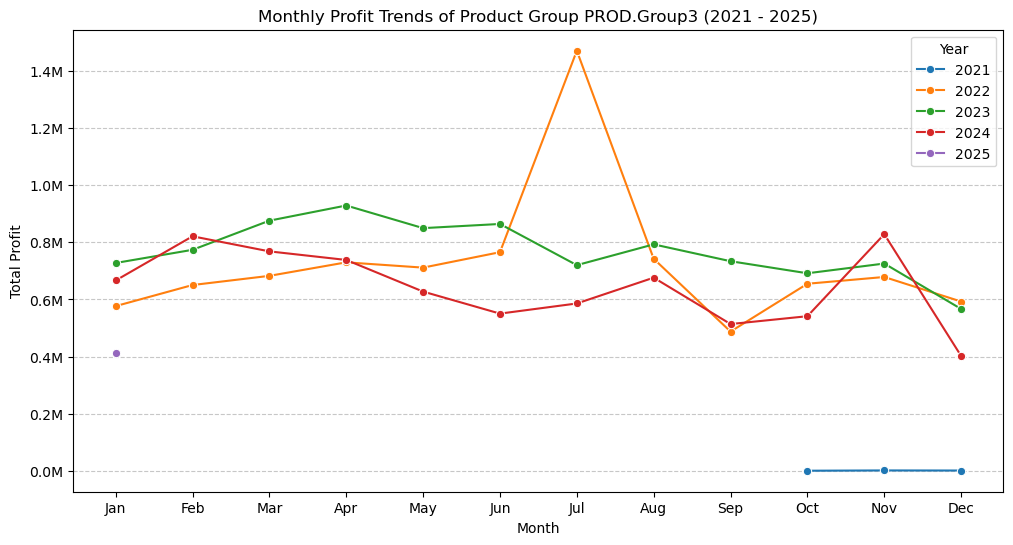

In [62]:
# Step 1: Identify the most profitable product group
most_profitable_group = product_profit.groupby("ProductGroupID").agg(TotalProfit=("TotalProfit", "sum")).reset_index()
most_profitable_group = most_profitable_group.sort_values(by="TotalProfit", ascending=False).iloc[0]["ProductGroupID"]

# Step 2: Filter the dataset for this product group
top_group_sales = df[df["ProductGroupID"] == most_profitable_group]

# Step 3: Aggregate monthly profit by year
monthly_trends_group = top_group_sales.groupby(["Year", "Month"]).agg(TotalProfit=("Profit", "sum")).reset_index()

# Step 4: Plot the monthly trends for each year
plt.figure(figsize=(12, 6))
sns.lineplot(x="Month", y="TotalProfit", hue="Year", data=monthly_trends_group, marker="o", palette="tab10")

# Formatting the graph
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(format_millions))
plt.title(f"Monthly Profit Trends of Product Group {most_profitable_group} (2021 - 2025)")
plt.xticks(ticks=range(1, 13), labels=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"])
plt.legend(title="Year")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()
